# 06 · VAE condicional

Entrena un autoencoder variacional condicionado al régimen sobre el bloque conjunto, con rampa de beta y free bits para evitar el colapso posterior.

**Entradas**

- `data/processed/ventanas.npz`

**Salidas**

- `models/generadores/cvae/ (modelo.pkl o .keras, historial.csv, meta.json)`
- `data/synthetic/cvae.npz`
- `results/figures/kl_por_dimension_cvae.png`

**Tiempo estimado:** ~25 min en CPU (200 épocas sobre ~3.500 ventanas).

**Independencia.** Este notebook solo lee `data/processed/ventanas.npz` (notebook 02) y solo escribe en `models/generadores/cvae/` y `data/synthetic/cvae.npz`. No depende de ningún otro notebook de generador ni de sus salidas, de modo que los notebooks 04 a 10 pueden ejecutarse en paralelo y en cualquier orden por distintas personas.

In [11]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import ventanas

part = ventanas.cargar_procesado()
train, val, test = part.train, part.val, part.test
print(train, val, test, sep="\n")

Conjunto(n=3696, X=(3696, 60, 20), 1970-01-01 a 1970-01-01)
Conjunto(n=672, X=(672, 60, 20), 1970-01-01 a 1970-01-01)
Conjunto(n=1052, X=(1052, 60, 20), 1970-01-01 a 1970-01-01)


In [13]:
from src import regimenes
from src.generadores import base

v = config.ventanas()
n_regimenes = config.n_regimenes()

bloque_train = ventanas.empaquetar(train)
print("bloque de train:", bloque_train.shape, "· d esperada:", ventanas.dimension_bloque(v))
regimenes.distribucion(train.y_reg, n_regimenes)

bloque de train: (3696, 1201) · d esperada: 1201


,muestras,porcentaje
regimen,,
0,2019,54.63
1,1090,29.49
2,587,15.88


## Cómo genera datos un VAE condicional

Un autoencoder tiene dos partes:

1. El **encoder** comprime cada ventana real de 1.201 valores en un vector
   latente de 32 números.
2. El **decoder** intenta reconstruir la ventana original utilizando esos
   32 números y el régimen de mercado.

Durante el entrenamiento el proceso es:

`ventana real + régimen → encoder → espacio latente → decoder → reconstrucción`

La diferencia entre un autoencoder normal y un VAE es que el VAE intenta organizar
los vectores latentes alrededor de una distribución normal estándar. Gracias a
esto, para generar una observación nueva podemos sortear:

\[
z \sim N(0,I)
\]

y pasarlo directamente al decoder junto con el régimen deseado:

`z aleatorio + régimen de crisis → decoder → ventana sintética de crisis`

El encoder solo se utiliza durante el entrenamiento. La generación utiliza
principalmente el decoder.

El régimen es una condición impuesta, no una variable reconstruida. Esto garantiza
que la etiqueta guardada sea la solicitada, aunque después debemos comprobar que
la ventana generada tenga realmente las características estadísticas de ese
régimen.

### Decisiones de entrenamiento

- La salida del decoder es lineal porque la mayoría de las entradas son variables
  estandarizadas que pueden tomar valores positivos y negativos.
- La rampa de `beta` evita penalizar demasiado pronto el espacio latente.
- Los `free bits` eliminan parte de la presión del KL sobre dimensiones con poca
  información. Ayudan a evitar el colapso, pero no garantizan por sí solos que
  todas las dimensiones sean útiles.

Una limitación actual es que `y_vol` no está estandarizada y ocupa solamente una de
las 1.201 coordenadas. Por ello puede tener muy poco peso en la reconstrucción.
En una siguiente versión convendría modelar `log(y_vol)` estandarizada con
estadísticos calculados exclusivamente sobre train.

In [14]:
bloque_val = ventanas.empaquetar(val)

generador = base.instanciar(
    "cvae",
    n_regimenes=n_regimenes,
    dim_latente=32,
    unidades_ocultas=512,
    beta=2.0,
    epocas_rampa_beta=30,
    free_bits=0.05,
    epocas=65,          # mejor validación de la ejecución inicial: época 64
    tam_lote=128,
    verboso=25,
)

generador.fit(
    bloque_train,
    train.y_reg,
    bloque_val=bloque_val,
    y_reg_val=val.y_reg,
)
generador

[cvae] época   25/65  total=    532.00  recon=    448.73  kl= 50.040  activas= 32/32
[cvae] época   50/65  total=    471.70  recon=    382.21  kl= 44.703  activas= 32/32


CVAE(nombre='cvae', d=1201, ajustado)

## Convergencia

Tres curvas que hay que leer juntas:

- **pérdida de reconstrucción**: debe bajar y aplanarse;
- **KL**: sube durante la rampa de beta y luego se estabiliza. Si cae a cero, el
  modelo ha colapsado y el decoder ignora el latente;
- **unidades activas**: cuántas de las 32 dimensiones latentes transportan
  información. Es el diagnóstico que dice si el cuello de botella está bien
  dimensionado.

Las curvas de validación son las que revelan el sobreajuste del decoder: si la
reconstrucción de train sigue bajando mientras la de validación sube, el modelo
está memorizando ventanas de entrenamiento.

,criterio,mejor_epoca,mejor_validacion,valor_final
0,pérdida total,64,1152.15,1152.15
1,reconstrucción,61,973.72,973.85


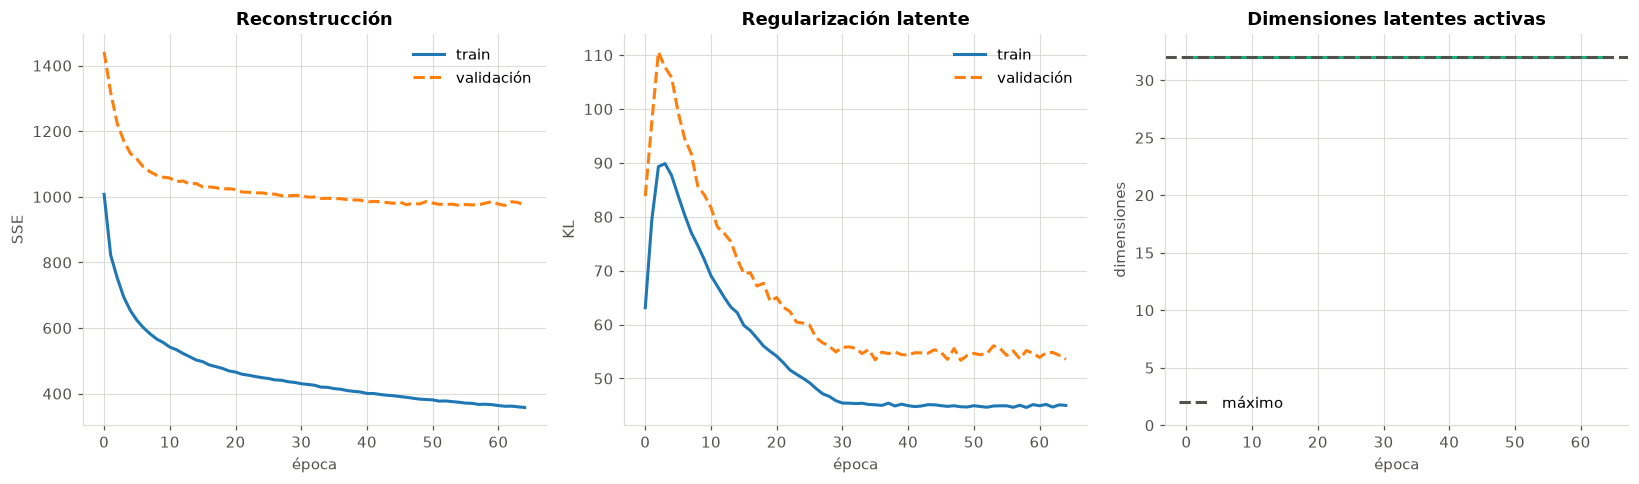

In [15]:
h = generador.historial
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))

# Reconstrucción
ejes[0].plot(h["epoca"], h["perdida_reconstruccion"], label="train")
ejes[0].plot(
    h["epoca"], h["val_perdida_reconstruccion"],
    linestyle="--", label="validación"
)
ejes[0].set_title("Reconstrucción")
ejes[0].set_xlabel("época")
ejes[0].set_ylabel("SSE")
ejes[0].legend()

# KL
ejes[1].plot(h["epoca"], h["perdida_kl"], label="train")
ejes[1].plot(
    h["epoca"], h["val_perdida_kl"],
    linestyle="--", label="validación"
)
ejes[1].set_title("Regularización latente")
ejes[1].set_xlabel("época")
ejes[1].set_ylabel("KL")
ejes[1].legend()

# Dimensiones activas
ejes[2].plot(h["epoca"], h["unidades_activas"], color=viz.PALETA[2])
ejes[2].axhline(
    generador.dim_latente,
    color=viz.TINTA_SECUNDARIA,
    linestyle="--",
    label="máximo"
)
ejes[2].set_ylim(0, generador.dim_latente + 2)
ejes[2].set_title("Dimensiones latentes activas")
ejes[2].set_xlabel("época")
ejes[2].set_ylabel("dimensiones")
ejes[2].legend()

fig.tight_layout()
viz.guardar(fig, "convergencia_cvae")

mejor_total = h["val_perdida_total"].idxmin()
mejor_recon = h["val_perdida_reconstruccion"].idxmin()

pd.DataFrame({
    "criterio": ["pérdida total", "reconstrucción"],
    "mejor_epoca": [
        int(h.loc[mejor_total, "epoca"]),
        int(h.loc[mejor_recon, "epoca"]),
    ],
    "mejor_validacion": [
        h.loc[mejor_total, "val_perdida_total"],
        h.loc[mejor_recon, "val_perdida_reconstruccion"],
    ],
    "valor_final": [
        h["val_perdida_total"].iloc[-1],
        h["val_perdida_reconstruccion"].iloc[-1],
    ],
}).round(2)

### Interpretación de la convergencia

La pérdida de entrenamiento disminuye durante las 200 épocas, pero la validación
alcanza su mínimo mucho antes:

- mejor pérdida total de validación: época 64, aproximadamente 1.152;
- pérdida total en la época final: aproximadamente 1.247;
- mejor reconstrucción de validación: época 61, aproximadamente 974;
- reconstrucción de validación final: aproximadamente 1.062.

Por tanto, continuar hasta la época 200 mejora el ajuste sobre train, pero empeora
la reconstrucción fuera de train. Esto puede deberse tanto a sobreajuste como al
cambio temporal de distribución entre train y validación.

El modelo exportado corresponde actualmente a la última época y no a la mejor.
En una siguiente versión debe utilizarse parada temprana con restauración de los
mejores pesos.

## Uso del espacio latente

El KL por dimensión y por época dice qué dimensiones aprende a usar el modelo y
cuándo. Una franja horizontal oscura es una dimensión activa; el resto son
dimensiones apagadas que el decoder ignora. Si casi todas están apagadas, sobra
cuello de botella o falta rampa.

Dimensiones activas al final: 32 de 32


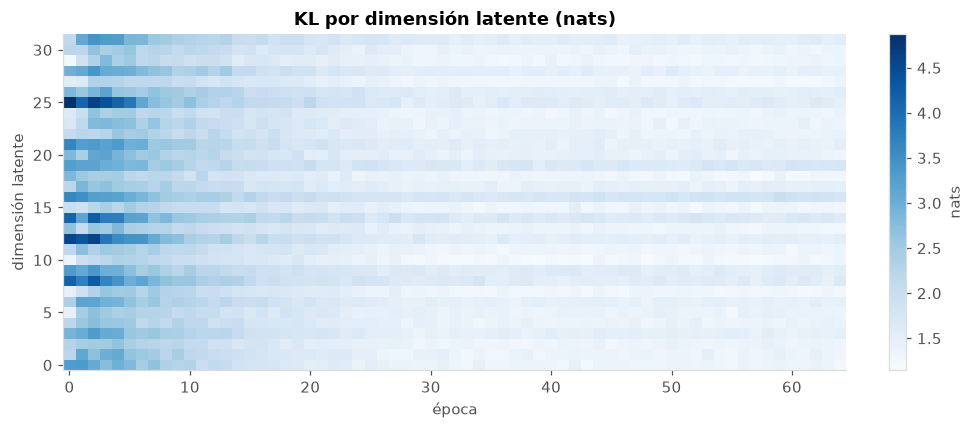

In [16]:
fig, eje = plt.subplots(figsize=(9, 4))

imagen = eje.imshow(
    generador.kl_por_dimension.T, aspect="auto", cmap="Blues", origin="lower"
)
eje.set_xlabel("época")
eje.set_ylabel("dimensión latente")
eje.set_title("KL por dimensión latente (nats)")
eje.grid(False)
fig.colorbar(imagen, ax=eje, fraction=0.046, label="nats")
viz.guardar(fig, "kl_por_dimension_cvae")

activas = (generador.kl_por_dimension[-1] > generador.umbral_unidad_activa).sum()
print("Dimensiones activas al final:", int(activas), "de", generador.dim_latente)

### Interpretación del espacio latente

Las 32 dimensiones latentes permanecen activas al final del entrenamiento y el KL
total se estabiliza alrededor de 46 nats. Por tanto, no se observa colapso
posterior: el decoder no está ignorando el vector latente.

Sin embargo, que las dimensiones estén activas no demuestra que la distribución
sintética sea correcta. El latente puede transportar información suficiente para
reconstruir train y, aun así, generar observaciones demasiado centradas cuando se
muestrea desde \(N(0,I)\).

El mapa KL debe interpretarse junto con la PCA y con las medidas de dispersión por
régimen.

## Inspección visual

Proyección PCA de reales y sintéticos, con la PCA ajustada **solo con los reales**
para que los ejes describan la estructura del mercado y no la del generador.

Es la comprobación más rápida y la que detecta los dos fallos gruesos: si la nube
sintética no cubre la real, el generador ha colapsado a un modo; si la desborda
ampliamente, está inventando configuraciones de mercado que nunca ocurrieron.

Se mira el régimen de crisis porque es el que tiene menos datos reales y, por
tanto, donde el generador tiene más margen para desviarse.

reales de crisis: 587 · sintéticos generados: 600


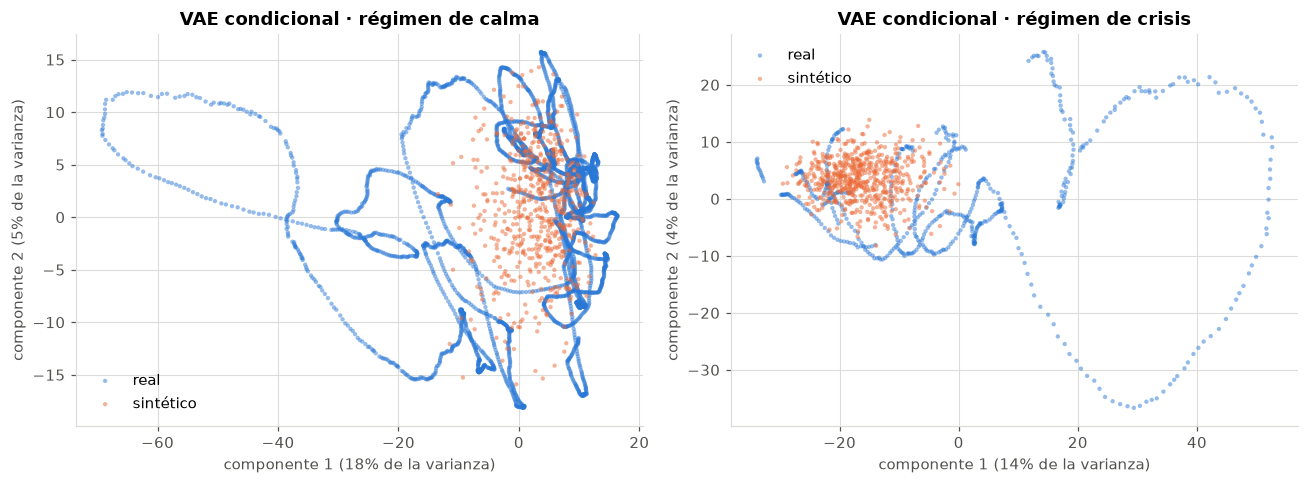

In [17]:
CRISIS = n_regimenes - 1

muestra_crisis = generador.generate(600, regimen=CRISIS)
reales_crisis = bloque_train[train.y_reg == CRISIS]

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
viz.real_vs_sintetico(bloque_train, generador.generate(600, regimen=0),
                      "{} · régimen de calma".format(generador.etiqueta), eje=ejes[0])
viz.real_vs_sintetico(reales_crisis, muestra_crisis,
                      "{} · régimen de crisis".format(generador.etiqueta), eje=ejes[1])
fig.tight_layout()
viz.guardar(fig, "pca_" + generador.nombre)

print("reales de crisis:", len(reales_crisis), "· sintéticos generados:", len(muestra_crisis))

### Interpretación de la PCA

La PCA muestra una diferencia clara entre la distribución real y la sintética.

En calma, los datos sintéticos se concentran en una parte de la nube real y no
reproducen todos sus recorridos. En crisis, la diferencia es mayor: las
observaciones reales cubren una región muy amplia, mientras que las sintéticas
permanecen cerca del centro.

Esto indica **infradispersión**: el CVAE produce escenarios plausibles y medios,
pero genera pocos episodios extremos. No se trata de colapso posterior, porque
todas las dimensiones latentes están activas, sino de una pérdida de variabilidad
al decodificar.

La PCA solo representa una fracción de la variabilidad total —aproximadamente
14–18 % en la primera componente y 4–5 % en la segunda—, por lo que debe
confirmarse con estadísticas calculadas en el espacio completo.

## Banco de muestras

Se genera un banco uniforme por régimen y se exporta a `data/synthetic/`. La mezcla
concreta de cada dataset la decide el notebook 11 muestreando de este banco, no
volviendo a invocar al generador: así el barrido no necesita tener los siete
modelos cargados en memoria y dos ejecuciones del notebook 12 usan exactamente las
mismas muestras sintéticas.

El banco es uniforme —no replica el desbalance real— porque la política de reparto
es un grado de libertad del experimento y se aplica después.

In [18]:
MUESTRAS_POR_REGIMEN = 3000

reparto = {k: MUESTRAS_POR_REGIMEN for k in range(n_regimenes)}
bloques_sint, y_sint = generador.generate_dataset(reparto)

print(
    "banco:", bloques_sint.shape,
    "· etiquetas:", np.bincount(y_sint, minlength=n_regimenes)
)
print("muestras finitas:", np.isfinite(bloques_sint).all())
print("volatilidades no positivas:", int((bloques_sint[:, -1] <= 0).sum()))

n_canales = train.X.shape[-1]
nombres_regimen = ["calma", "intermedio", "crisis"]
filas = []

for k in range(n_regimenes):
    real = bloque_train[train.y_reg == k]
    sintetico = bloques_sint[y_sint == k]

    vol_real = real[:, -1]
    vol_sint = sintetico[:, -1]

    X_real = real[:, :-1].reshape(-1, v.pasado, n_canales)
    X_sint = sintetico[:, :-1].reshape(-1, v.pasado, n_canales)

    vol_pasada_real = X_real[:, :, 0].std(axis=1)
    vol_pasada_sint = X_sint[:, :, 0].std(axis=1)

    filas.append({
        "regimen": nombres_regimen[k],
        "n_real": len(real),
        "n_sint": len(sintetico),
        "std_X_real": real[:, :-1].std(),
        "std_X_sint": sintetico[:, :-1].std(),
        "ratio_dispersion_X": sintetico[:, :-1].std() / real[:, :-1].std(),
        "media_vol_real": vol_real.mean(),
        "media_vol_sint": vol_sint.mean(),
        "std_vol_real": vol_real.std(),
        "std_vol_sint": vol_sint.std(),
        "p90_vol_real": np.quantile(vol_real, 0.90),
        "p90_vol_sint": np.quantile(vol_sint, 0.90),
        "p99_vol_real": np.quantile(vol_real, 0.99),
        "p99_vol_sint": np.quantile(vol_sint, 0.99),
        "corr_pasado_futuro_real": np.corrcoef(
            vol_pasada_real, vol_real
        )[0, 1],
        "corr_pasado_futuro_sint": np.corrcoef(
            vol_pasada_sint, vol_sint
        )[0, 1],
    })

auditoria_regimen = pd.DataFrame(filas).set_index("regimen")
auditoria_regimen.round(3)

banco: (9000, 1201) · etiquetas: [3000 3000 3000]
muestras finitas: True
volatilidades no positivas: 1


,n_real,n_sint,std_X_real,std_X_sint,ratio_dispersion_X,media_vol_real,media_vol_sint,std_vol_real,std_vol_sint,p90_vol_real,p90_vol_sint,p99_vol_real,p99_vol_sint,corr_pasado_futuro_real,corr_pasado_futuro_sint
regimen,,,,,,,,,,,,,,,
calma,2019,3000,0.715,0.500,0.700,0.096,0.107,0.030,0.031,0.133,0.146,0.209,0.188,0.150,0.274
intermedio,1090,3000,0.940,0.552,0.588,0.164,0.159,0.046,0.036,0.219,0.204,0.297,0.260,0.155,0.285
crisis,587,3000,1.702,0.603,0.355,0.323,0.235,0.159,0.045,0.552,0.296,0.830,0.354,0.497,0.357


### Fidelidad por régimen

La pérdida de variabilidad aumenta con la severidad del régimen:

- calma conserva aproximadamente el 75 % de la dispersión real;
- el régimen intermedio conserva aproximadamente el 67 %;
- crisis conserva solamente el 45 %.

El problema es especialmente visible en `y_vol` de crisis. Su desviación pasa de
aproximadamente 0,159 en los datos reales a 0,051 en los sintéticos. El percentil
90 baja de 0,552 a 0,318 y el máximo generado es aproximadamente 0,504, frente a
0,854 en train.

También se debilita la relación entre la volatilidad de la ventana y la
volatilidad futura: la correlación en crisis pasa de aproximadamente 0,50 en los
reales a 0,21 en los sintéticos.

Por tanto, el CVAE distingue los regímenes y genera observaciones finitas, pero
suaviza precisamente los escenarios extremos que se pretende aumentar. Antes de
considerarlo un generador definitivo conviene:

1. estandarizar `log(y_vol)`;
2. equilibrar los regímenes durante el entrenamiento;
3. restaurar los pesos de mejor validación;
4. seleccionar `beta` según la fidelidad del régimen de crisis.

## Conclusión del CVAE

El entrenamiento es estable, no presenta valores no finitos y utiliza todo el
espacio latente. El condicionamiento también permite generar exactamente 3.000
observaciones etiquetadas de cada régimen.

No obstante, la ejecución actual no reproduce completamente la distribución real.
Los sintéticos presentan menor dispersión y colas más cortas, sobre todo en crisis.
Por ello, este banco puede conservarse como resultado experimental para compararlo
con los demás generadores, pero no debe describirse como una réplica de la
distribución real.

Además, el banco global es uniforme por régimen, mientras que train está
desbalanceado. En consecuencia, la distribución global del banco tampoco debe
compararse directamente con la global real sin igualar previamente las
proporciones de regímenes.

## Persistencia

`guardar()` deja el modelo, la curva de convergencia y los metadatos en
`models/generadores/`. Es lo que permite que el resto del grupo salte directamente
al análisis sin reentrenar nada.

In [19]:
ruta_muestras = generador.exportar_muestras(bloques_sint, y_sint)
ruta_modelo = generador.guardar()

print("muestras:", ruta_muestras)
print("modelo:  ", ruta_modelo)
pd.Series(generador.resumen_convergencia()).round(4)

muestras: C:\Users\Fernando Dapena T\Desktop\Taller B5-T1\TALLER_GENERATIVOS\data\synthetic\cvae.npz
modelo:   C:\Users\Fernando Dapena T\Desktop\Taller B5-T1\TALLER_GENERATIVOS\models\generadores\cvae


final_epoca                           64.0000
final_beta                             2.0000
final_perdida_total                  447.8063
final_perdida_reconstruccion         357.8802
final_perdida_kl                      44.9970
final_val_perdida_total             1152.1543
final_val_perdida_reconstruccion     973.8535
final_val_perdida_kl                  53.5654
final_unidades_activas                32.0000
dtype: float64

## Salidas generadas

In [20]:
from pathlib import Path

salidas = [
    src.DIR_MODELOS_GEN / "cvae" / "meta.json",
    src.DIR_MODELOS_GEN / "cvae" / "historial.csv",
    src.DIR_SINTETICO / "cvae.npz",
    src.DIR_FIGURAS / "convergencia_cvae.png",
    src.DIR_FIGURAS / "pca_cvae.png",
    src.DIR_FIGURAS / "kl_por_dimension_cvae.png",
]

for ruta in salidas:
    ruta = Path(ruta)
    marca = "ok" if ruta.exists() else "--"
    print("[{}] {}".format(marca, ruta.relative_to(src.RAIZ)))


[ok] models\generadores\cvae\meta.json
[ok] models\generadores\cvae\historial.csv
[ok] data\synthetic\cvae.npz
[ok] results\figures\convergencia_cvae.png
[ok] results\figures\pca_cvae.png
[ok] results\figures\kl_por_dimension_cvae.png
